Alunos: Gabriel Schaldach Morgado, Eduardo Lechinski Ramos

Trabalho M1 - Inteligência Artificial

Encaminhamento: https://docs.google.com/document/d/1Cl0L9yJN01gSwmXidKAYI-Bkn9OiiUAO4svEbbnruaE/edit?usp=sharing

Documentação dataset: https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets?hl=pt-br

link do overleaf: https://www.overleaf.com/6897273326jxpwvnjfcgzv#503319

streamlit: https://m1ai-uni.streamlit.app/

# 1. Análise Exploratória de Dados (AED)

## 1.1 Inspeção inicial

In [32]:
### Instalando pacote do dataset (código fornecido)
!pip install ucimlrepo

In [33]:
# Importando pacotes principais

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, initializers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight
from ucimlrepo import fetch_ucirepo

In [71]:
# fetch dataset
dry_bean = fetch_ucirepo(id=602)

# data (as pandas dataframes)
X = dry_bean.data.features
y = dry_bean.data.targets

# metadata
print(dry_bean.metadata)

# variable information
print(dry_bean.variables)



{'uci_id': 602, 'name': 'Dry Bean', 'repository_url': 'https://archive.ics.uci.edu/dataset/602/dry+bean+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/602/data.csv', 'abstract': 'Images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. A total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 13611, 'num_features': 16, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C50S4B', 'creators': [], 'intro_paper': {'ID': 244, 'type': 'NATIVE', 'title': 'Multiclass classification of dry beans using computer vision and machine learning techniques', 'authors': 'M. Koklu, Ilker Ali Özkan', 'venue': 'Co

In [35]:
# Observando classes alvo
y.value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [36]:
# Verificando tamanho do dataset
y.shape

(13611, 1)

In [37]:
X.shape

(13611, 16)

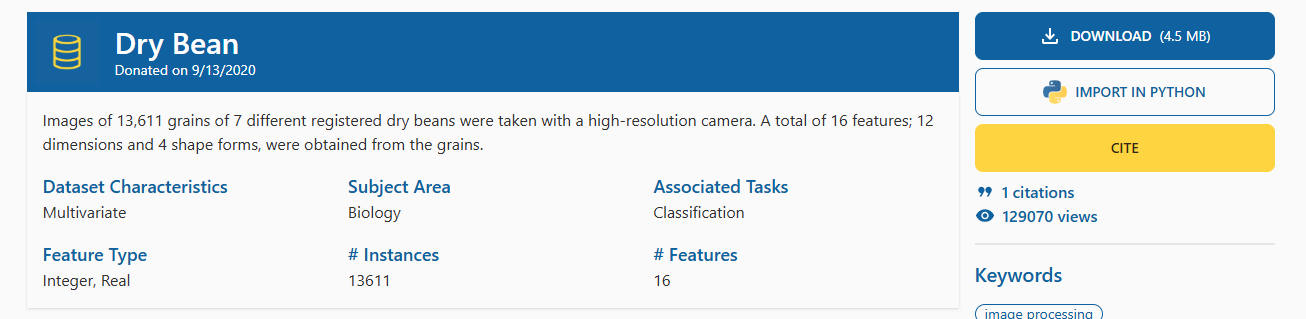

## 1.2 Verificação e remoção de duplicatas

In [38]:
# Verificando registros duplicados
X.duplicated().sum()

np.int64(68)

In [39]:
pd.concat([X, y], axis = 1).duplicated().sum()

np.int64(68)

In [40]:
X.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='object')

## 1.3 Distribuição das features

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Perimeter'}>,
        <Axes: title={'center': 'MajorAxisLength'}>,
        <Axes: title={'center': 'MinorAxisLength'}>],
       [<Axes: title={'center': 'AspectRatio'}>,
        <Axes: title={'center': 'Eccentricity'}>,
        <Axes: title={'center': 'ConvexArea'}>,
        <Axes: title={'center': 'EquivDiameter'}>],
       [<Axes: title={'center': 'Extent'}>,
        <Axes: title={'center': 'Solidity'}>,
        <Axes: title={'center': 'Roundness'}>,
        <Axes: title={'center': 'Compactness'}>],
       [<Axes: title={'center': 'ShapeFactor1'}>,
        <Axes: title={'center': 'ShapeFactor2'}>,
        <Axes: title={'center': 'ShapeFactor3'}>,
        <Axes: title={'center': 'ShapeFactor4'}>]], dtype=object)

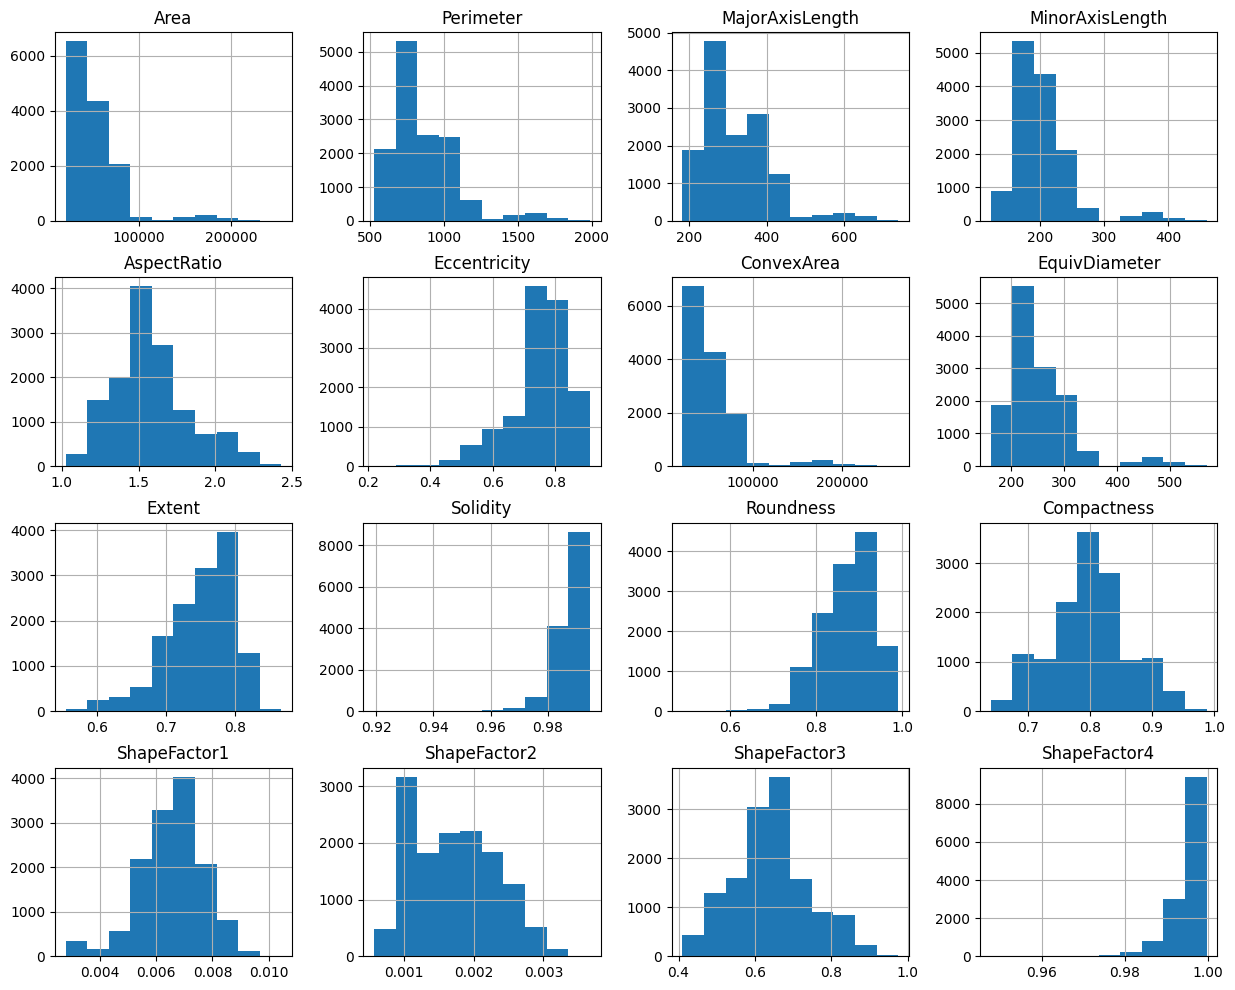

In [41]:
# Fazendo histograma
X.hist(figsize = (15,12))

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Perimeter'}>,
        <Axes: title={'center': 'MajorAxisLength'}>,
        <Axes: title={'center': 'MinorAxisLength'}>],
       [<Axes: title={'center': 'AspectRatio'}>,
        <Axes: title={'center': 'Eccentricity'}>,
        <Axes: title={'center': 'ConvexArea'}>,
        <Axes: title={'center': 'EquivDiameter'}>],
       [<Axes: title={'center': 'Extent'}>,
        <Axes: title={'center': 'Solidity'}>,
        <Axes: title={'center': 'Roundness'}>,
        <Axes: title={'center': 'Compactness'}>],
       [<Axes: title={'center': 'ShapeFactor1'}>,
        <Axes: title={'center': 'ShapeFactor2'}>,
        <Axes: title={'center': 'ShapeFactor3'}>,
        <Axes: title={'center': 'ShapeFactor4'}>]], dtype=object)

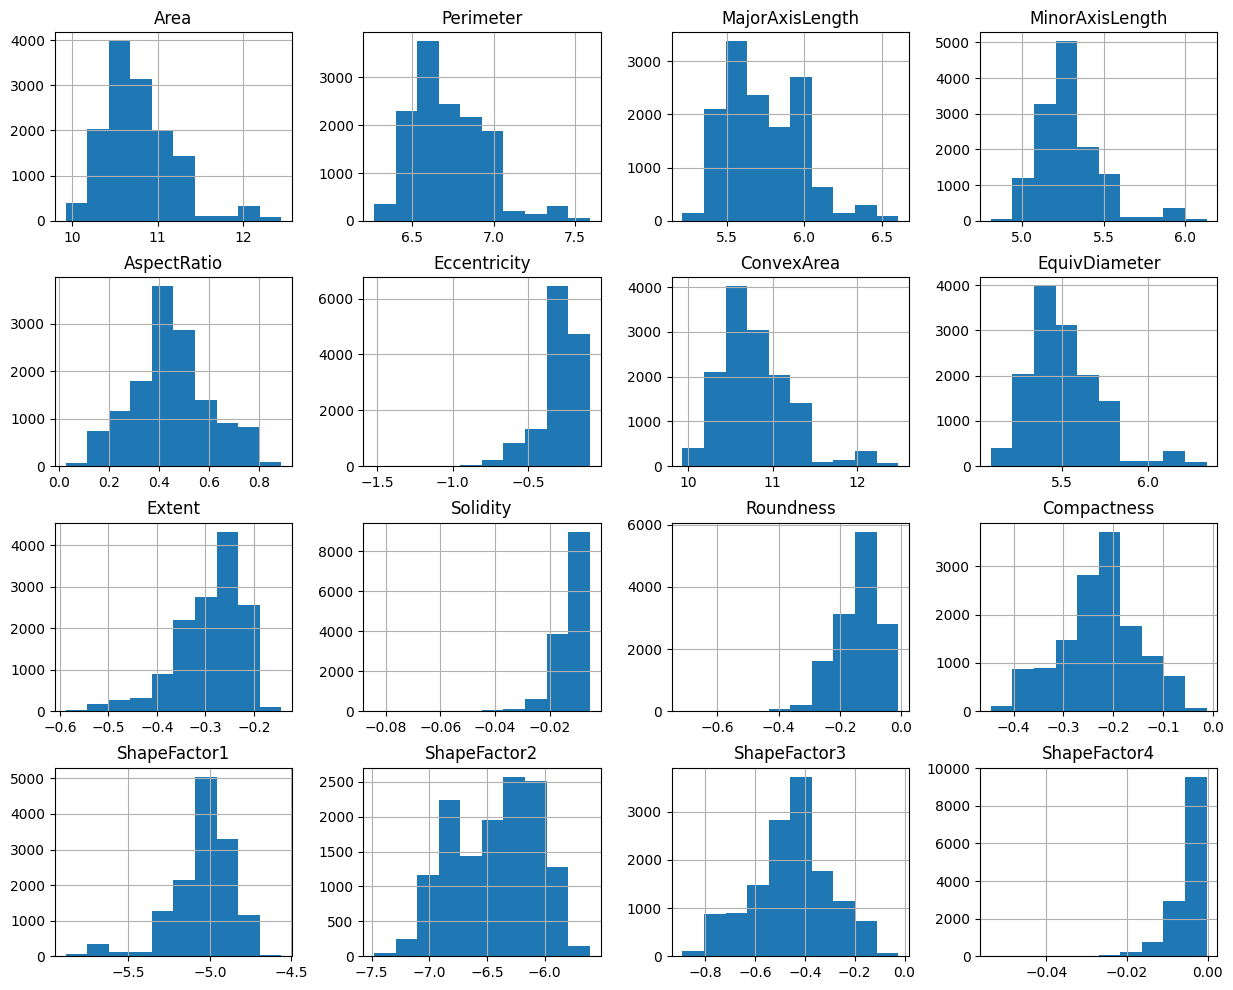

In [42]:
# Fazendo histogramas com transformação logarítmica
X.transform(np.log).hist(figsize = (15,12))

## 1.4 Análise e correlação de Pearson

<Axes: >

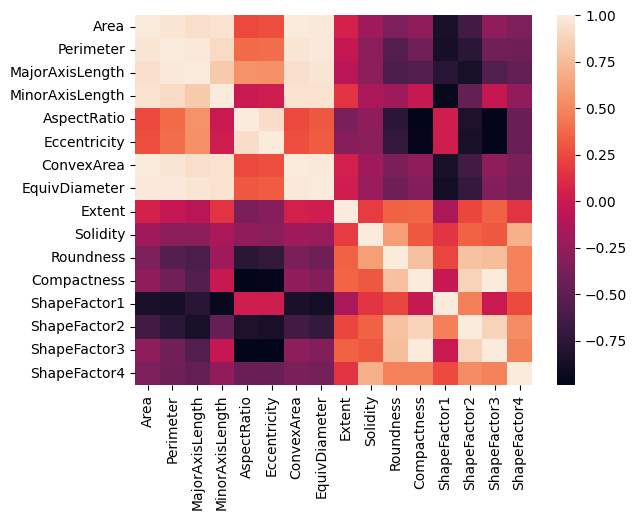

In [43]:
sns.heatmap(X.corr())

In [44]:
X.corr()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Area,1.000000,0.966722,0.931834,0.951602,0.241735,0.267481,0.999939,0.984968,0.054345,-0.196585,-0.357530,-0.268067,-0.847958,-0.639291,-0.272145,-0.355721
Perimeter,0.966722,1.000000,0.977338,0.913179,0.385276,0.391066,0.967689,0.991380,-0.021160,-0.303970,-0.547647,-0.406857,-0.864623,-0.767592,-0.408435,-0.429310
MajorAxisLength,0.931834,0.977338,1.000000,0.826052,0.550335,0.541972,0.932607,0.961733,-0.078062,-0.284302,-0.596358,-0.568377,-0.773609,-0.859238,-0.568185,-0.482527
MinorAxisLength,0.951602,0.913179,0.826052,1.000000,-0.009161,0.019574,0.951339,0.948539,0.145957,-0.155831,-0.210344,-0.015066,-0.947204,-0.471347,-0.019326,-0.263749
AspectRatio,0.241735,0.385276,0.550335,-0.009161,1.000000,0.924293,0.243301,0.303647,-0.370184,-0.267754,-0.766979,-0.987687,0.024593,-0.837841,-0.978592,-0.449264
Eccentricity,0.267481,0.391066,0.541972,0.019574,0.924293,1.000000,0.269255,0.318667,-0.319362,-0.297592,-0.722272,-0.970313,0.019920,-0.860141,-0.981058,-0.449354
ConvexArea,0.999939,0.967689,0.932607,0.951339,0.243301,0.269255,1.000000,0.985226,0.052564,-0.206191,-0.362083,-0.269922,-0.847950,-0.640862,-0.274024,-0.362049
EquivDiameter,0.984968,0.991380,0.961733,0.948539,0.303647,0.318667,0.985226,1.000000,0.028383,-0.231648,-0.435945,-0.327650,-0.892741,-0.713069,-0.330389,-0.392512
Extent,0.054345,-0.021160,-0.078062,0.145957,-0.370184,-0.319362,0.052564,0.028383,1.000000,0.191389,0.344411,0.354212,-0.141616,0.237956,0.347624,0.148502
Solidity,-0.196585,-0.303970,-0.284302,-0.155831,-0.267754,-0.297592,-0.206191,-0.231648,0.191389,1.000000,0.607150,0.303766,0.153388,0.343559,0.307662,0.702163


## 1.5 Boxplots por classe

/tmp/ipykernel_1615/1561391543.py:3: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  pd.concat([X, y], axis = 1).boxplot(column = ["Area", "Eccentricity", "Roundness", "ShapeFactor1", "MajorAxisLength", "Extent"], by = "Class", ax = axes)


array([<Axes: title={'center': 'Area'}, xlabel='Class'>,
       <Axes: title={'center': 'Eccentricity'}, xlabel='Class'>,
       <Axes: title={'center': 'Roundness'}, xlabel='Class'>,
       <Axes: title={'center': 'ShapeFactor1'}, xlabel='Class'>,
       <Axes: title={'center': 'MajorAxisLength'}, xlabel='Class'>,
       <Axes: title={'center': 'Extent'}, xlabel='Class'>], dtype=object)

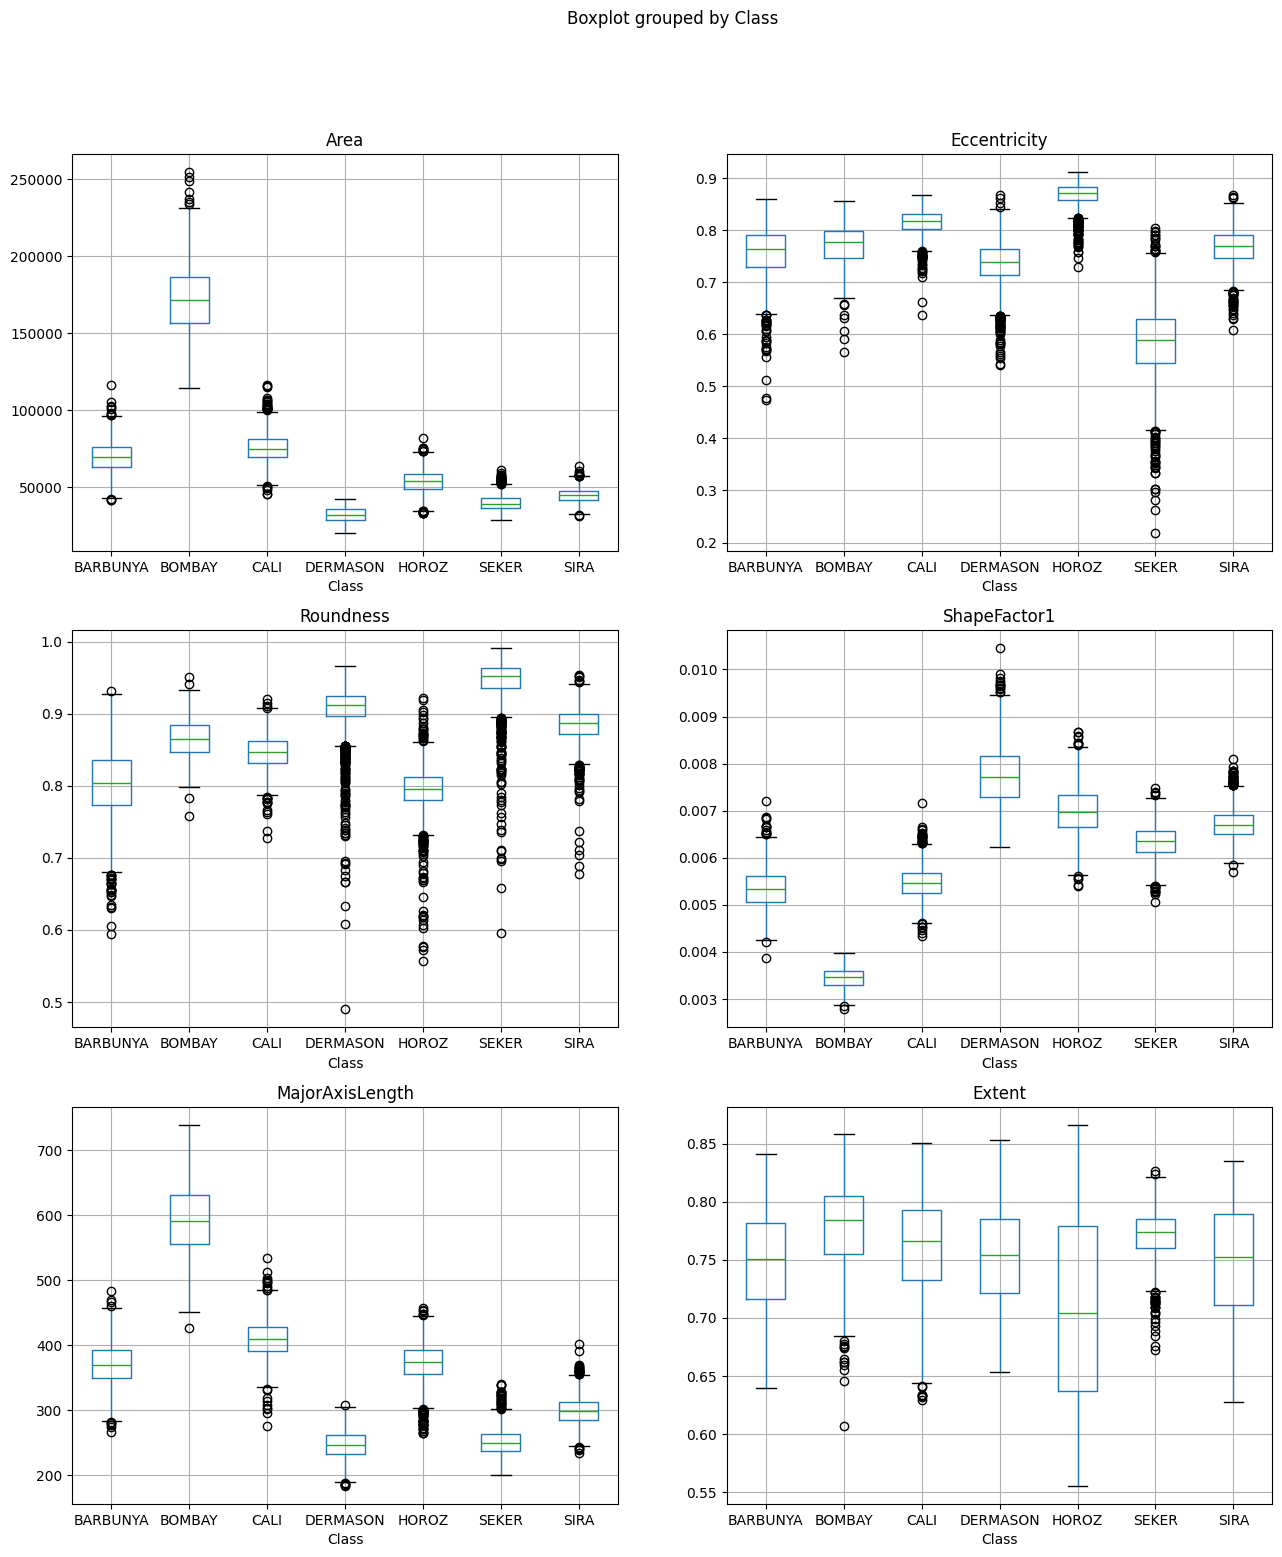

In [45]:
fig, axes = plt.subplots(3,2,sharex=False,sharey=False, figsize = (15,18))

pd.concat([X, y], axis = 1).boxplot(column = ["Area", "Eccentricity", "Roundness", "ShapeFactor1", "MajorAxisLength", "Extent"], by = "Class", ax = axes)

# 2. Pré-processamento

## 2.1. Codificação da variável alvo

In [46]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([5, 5, 5, ..., 3, 3, 3])

## 2.2 Normalização das features

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.84074853, -1.1433189 , -1.30659814, ...,  2.4021726 ,
         1.92572347,  0.83837102],
       [-0.82918764, -1.01392388, -1.39591111, ...,  3.10089364,
         2.68970162,  0.77113831],
       [-0.80715717, -1.07882906, -1.25235661, ...,  2.23509111,
         1.84135576,  0.91675506],
       ...,
       [-0.37203825, -0.44783294, -0.45047814, ...,  0.28920501,
         0.33632829,  0.39025106],
       [-0.37176543, -0.42702856, -0.42897404, ...,  0.22837456,
         0.2489734 ,  0.03644007],
       [-0.37135619, -0.38755718, -0.2917356 , ..., -0.12777538,
        -0.27648141,  0.71371941]])

## 2.3 Tratamento do desbalanceamento com class_weight

In [48]:
classes_unicas = np.unique(y_encoded)
pesos = compute_class_weight(
    class_weight="balanced", classes=classes_unicas, y=y_encoded
)
class_weight_dict = dict(zip(classes_unicas, pesos))

print("Pesos por classe (balanced):")
for idx, nome in enumerate(le.classes_):
    print(f"  {nome:12s} (índice {idx}): {class_weight_dict[idx]:.4f}")

Pesos por classe (balanced):
  BARBUNYA     (índice 0): 1.4708
  BOMBAY       (índice 1): 3.7250
  CALI         (índice 2): 1.1929
  DERMASON     (índice 3): 0.5483
  HOROZ        (índice 4): 1.0085
  SEKER        (índice 5): 0.9593
  SIRA         (índice 6): 0.7376


## 2.4 Divisão treino / validação / teste

In [49]:
X_arr = X.values

# 1ª divisão: 80 % treino+val  /  20 % teste
X_trainval, X_test_raw, y_trainval, y_test = train_test_split(
    X_arr, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# 2ª divisão: 75 % treino  /  25 % validação (do conjunto de 80 %)
# → resulta em 60 % treino e 20 % validação do total
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Treino    : {X_train_raw.shape[0]} amostras")
print(f"Validação : {X_val_raw.shape[0]} amostras")
print(f"Teste     : {X_test_raw.shape[0]} amostras")


scaler_final = StandardScaler()
X_train = scaler_final.fit_transform(X_train_raw)
X_val = scaler_final.transform(X_val_raw)
X_test = scaler_final.transform(X_test_raw)

Treino    : 8166 amostras
Validação : 2722 amostras
Teste     : 2723 amostras


# 3. Construção, treinamento e experimentos

In [50]:
colunas = list(X.columns)
features_sel = [
    "Area",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRatio",
    "Eccentricity",
    "Extent",
    "Solidity",
    "Roundness",
    "Compactness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]
idx_sel = [colunas.index(f) for f in features_sel]

X_train_sel = X_train[:, idx_sel]
X_val_sel = X_val[:, idx_sel]
X_test_sel = X_test[:, idx_sel]

nomes_classes = list(le.classes_)
N_CLASSES = len(nomes_classes)


## Helpers


In [51]:
def construir_modelo(
    n_entrada, unidades, taxas_dropout, inicializador="he_normal", lr=1e-3
):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(n_entrada,)))
    for u, d in zip(unidades, taxas_dropout):
        modelo.add(layers.Dense(u, activation="relu", kernel_initializer=inicializador))
        if d is not None and d > 0:
            modelo.add(layers.Dropout(d))
    modelo.add(layers.Dense(N_CLASSES, activation="softmax"))

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


def treinar(modelo, X_tr, y_tr, X_v, y_v, batch_size=64, epocas=300, usar_pesos=False):
    cb_early = callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    pesos = class_weight_dict if usar_pesos else None

    historico = modelo.fit(
        X_tr,
        y_tr,
        validation_data=(X_v, y_v),
        epochs=epocas,
        batch_size=batch_size,
        callbacks=[cb_early],
        class_weight=pesos,
        verbose=0,
    )
    return historico

# IA generativa para gerar plots *
def plotar_curvas(historico, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(historico.history["loss"], label="treino")
    axes[0].plot(historico.history["val_loss"], label="validação")
    axes[0].set_title(f"{titulo} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(historico.history["accuracy"], label="treino")
    axes[1].plot(historico.history["val_accuracy"], label="validação")
    axes[1].set_title(f"{titulo} — Acurácia")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Acurácia")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def avaliar(modelo, X_te, y_te):
    y_pred = modelo.predict(X_te, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    print(f"  Acurácia  : {acc:.4f}")
    print(f"  F1-macro  : {f1m:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=nomes_classes))
    return acc, f1m, y_pred


resultados = []

## Experimento A — Sem Dropout (referência)

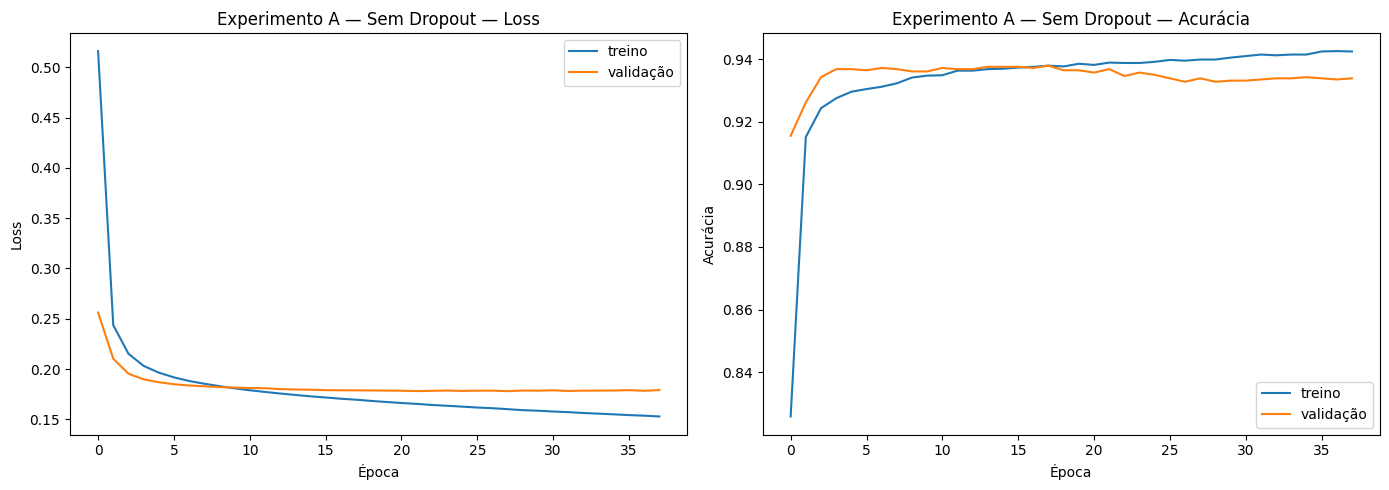

=== Experimento A — Sem Dropout ===
  Acurácia  : 0.9254
  F1-macro  : 0.9362

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.90      0.92       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.92      0.95      0.94       326
    DERMASON       0.90      0.93      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.89      0.85      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [52]:
tf.random.set_seed(42)
modelo_A = construir_modelo(
    n_entrada=X_train.shape[1],
    unidades=[128, 64],
    taxas_dropout=[None, None],
)
historico_A = treinar(modelo_A, X_train, y_train, X_val, y_val, usar_pesos=False)
plotar_curvas(historico_A, "Experimento A — Sem Dropout")

print("=== Experimento A — Sem Dropout ===")
acc_A, f1_A, _ = avaliar(modelo_A, X_test, y_test)

## Experimento A2 — Com Dropout

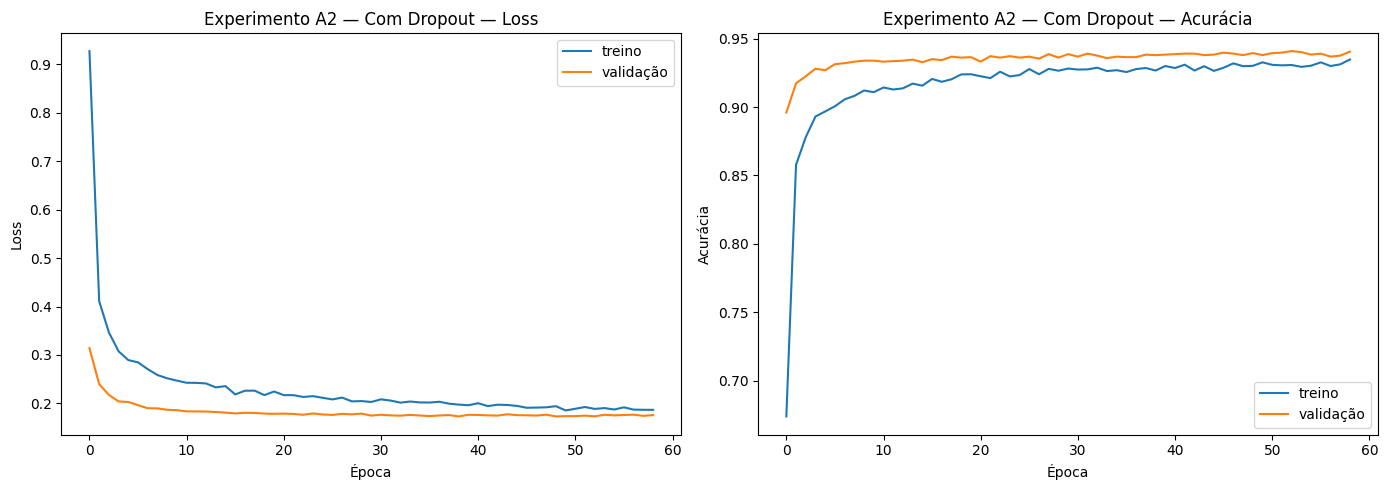

=== Experimento A2 — Com Dropout ===
  Acurácia  : 0.9247
  F1-macro  : 0.9358

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.88      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



In [53]:

tf.random.set_seed(42)
modelo_A2 = construir_modelo(
    n_entrada=X_train.shape[1], unidades=[128, 64], taxas_dropout=[0.3, 0.2]
)
historico_A2 = treinar(modelo_A2, X_train, y_train, X_val, y_val, usar_pesos=False)
plotar_curvas(historico_A2, "Experimento A2 — Com Dropout")

print("=== Experimento A2 — Com Dropout ===")
acc_A2, f1_A2, _ = avaliar(modelo_A2, X_test, y_test)

## Experimento B — class_weight

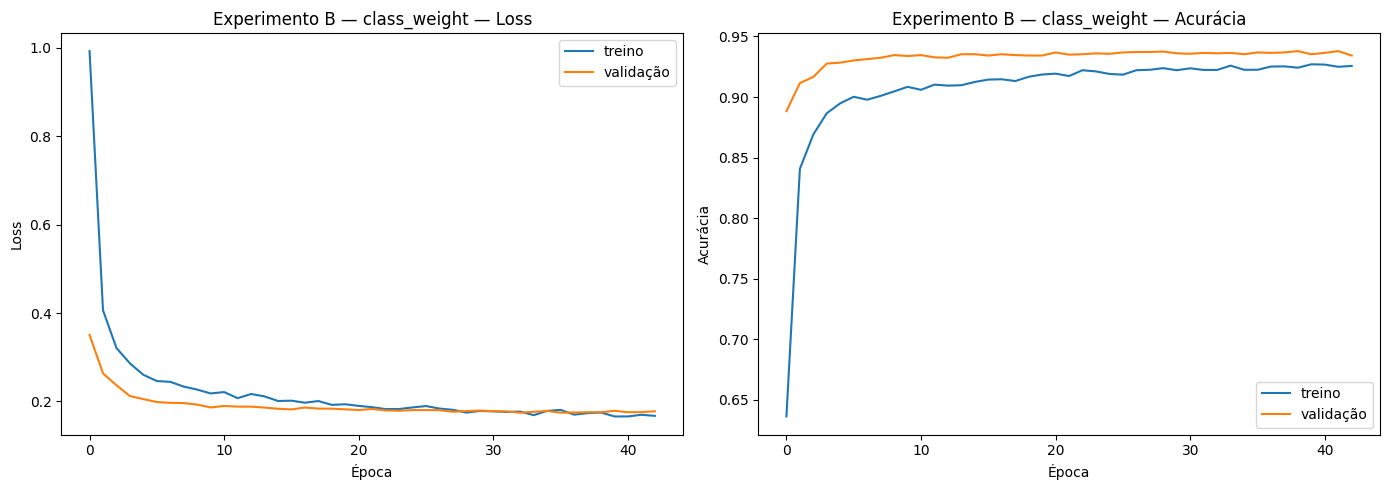

=== Experimento B — class_weight ===
  Acurácia  : 0.9269
  F1-macro  : 0.9377

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.88      0.88       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [54]:
tf.random.set_seed(42)
modelo_B = construir_modelo(
    n_entrada=X_train.shape[1], unidades=[128, 64], taxas_dropout=[0.3, 0.2]
)
historico_B = treinar(
    modelo_B, X_train, y_train, X_val, y_val, usar_pesos=True
)
plotar_curvas(historico_B, "Experimento B — class_weight")

print("=== Experimento B — class_weight ===")
acc_B, f1_B, _ = avaliar(modelo_B, X_test, y_test)


## Experimento C — Rede maior (3 camadas ocultas)

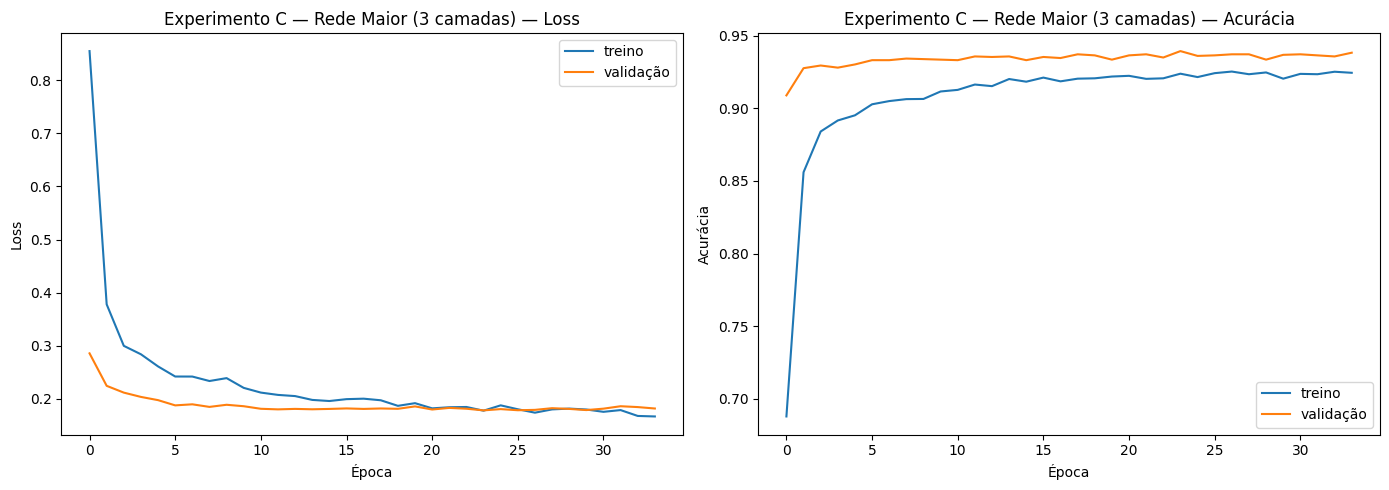

=== Experimento C — Rede Maior ===
  Acurácia  : 0.9258
  F1-macro  : 0.9376

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.95      0.95       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.95      0.97      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.88      0.86      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [55]:
tf.random.set_seed(42)
modelo_C = construir_modelo(
    n_entrada=X_train.shape[1], unidades=[256, 128, 64], taxas_dropout=[0.3, 0.3, 0.2]
)
historico_C = treinar(modelo_C, X_train, y_train, X_val, y_val, usar_pesos=True)
plotar_curvas(historico_C, "Experimento C — Rede Maior (3 camadas)")

print("=== Experimento C — Rede Maior ===")
acc_C, f1_C, _ = avaliar(modelo_C, X_test, y_test)



## Experimento D — Inicializador diferente

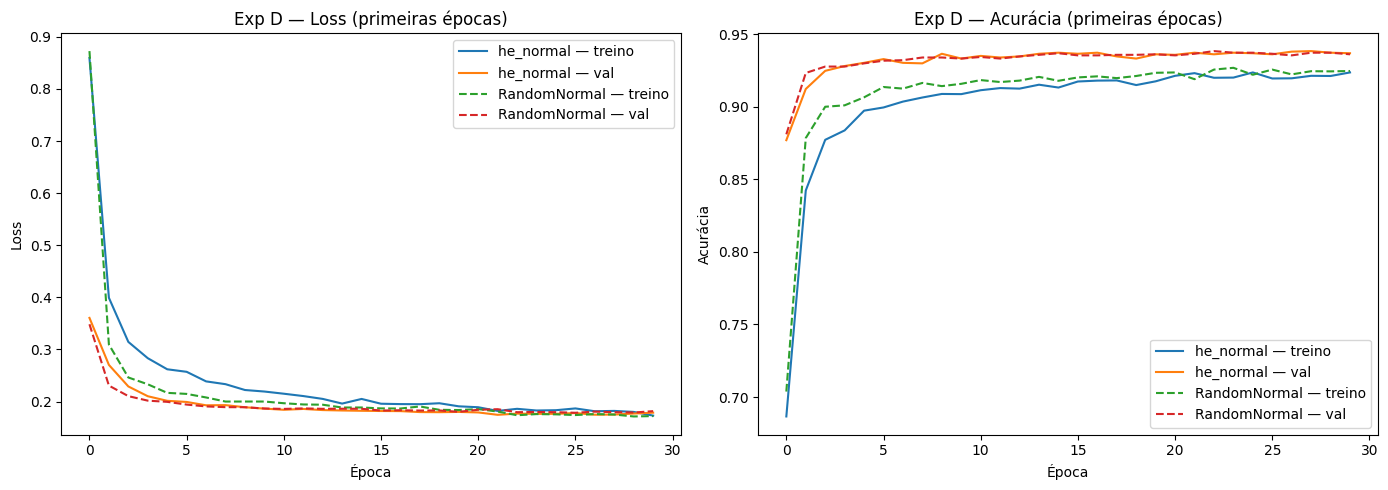

=== Experimento D1 — he_normal ===
  Acurácia  : 0.9243
  F1-macro  : 0.9351

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.95      0.96      0.95       386
       SEKER       0.93      0.96      0.95       406
        SIRA       0.87      0.88      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723

=== Experimento D2 — RandomNormal ===
  Acurácia  : 0.9229
  F1-macro  : 0.9345

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.92    

In [56]:
#uso de IA generativa para plots*

tf.random.set_seed(42)
modelo_D1 = construir_modelo(
    n_entrada=X_train.shape[1],
    unidades=[128, 64],
    taxas_dropout=[0.3, 0.2],
    inicializador="he_normal",
)
historico_D1 = treinar(modelo_D1, X_train, y_train, X_val, y_val, usar_pesos=True)


tf.random.set_seed(42)
modelo_D2 = construir_modelo(
    n_entrada=X_train.shape[1],
    unidades=[128, 64],
    taxas_dropout=[0.3, 0.2],
    inicializador=initializers.RandomNormal(mean=0.0, stddev=0.05),
)
historico_D2 = treinar(modelo_D2, X_train, y_train, X_val, y_val, usar_pesos=True)


epocas_plot = min(
    30, len(historico_D1.history["loss"]), len(historico_D2.history["loss"])
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historico_D1.history["loss"][:epocas_plot], label="he_normal — treino")
axes[0].plot(historico_D1.history["val_loss"][:epocas_plot], label="he_normal — val")
axes[0].plot(
    historico_D2.history["loss"][:epocas_plot],
    label="RandomNormal — treino",
    linestyle="--",
)
axes[0].plot(
    historico_D2.history["val_loss"][:epocas_plot],
    label="RandomNormal — val",
    linestyle="--",
)
axes[0].set_title("Exp D — Loss (primeiras épocas)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(historico_D1.history["accuracy"][:epocas_plot], label="he_normal — treino")
axes[1].plot(
    historico_D1.history["val_accuracy"][:epocas_plot], label="he_normal — val"
)
axes[1].plot(
    historico_D2.history["accuracy"][:epocas_plot],
    label="RandomNormal — treino",
    linestyle="--",
)
axes[1].plot(
    historico_D2.history["val_accuracy"][:epocas_plot],
    label="RandomNormal — val",
    linestyle="--",
)
axes[1].set_title("Exp D — Acurácia (primeiras épocas)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
plt.tight_layout()
plt.show()

print("=== Experimento D1 — he_normal ===")
acc_D1, f1_D1, _ = avaliar(modelo_D1, X_test, y_test)
print("=== Experimento D2 — RandomNormal ===")
acc_D2, f1_D2, _ = avaliar(modelo_D2, X_test, y_test)


## Experimento E — Features selecionadas na AED

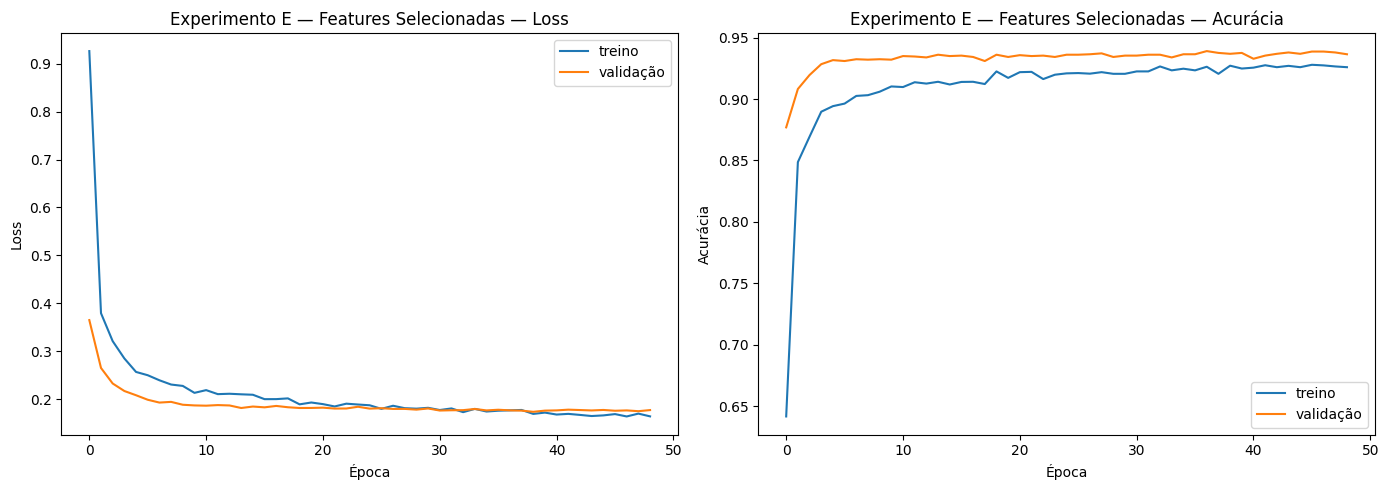

=== Experimento E — Features selecionadas ===
  Acurácia  : 0.9240
  F1-macro  : 0.9368

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.93      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.95      0.95      0.95       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.95      0.96      0.95       386
       SEKER       0.93      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



In [61]:

tf.random.set_seed(42)
modelo_E = construir_modelo(
    n_entrada=X_train_sel.shape[1],
    unidades=[128, 64],
    taxas_dropout=[0.3, 0.2],
)
historico_E = treinar(modelo_E, X_train_sel, y_train, X_val_sel, y_val, usar_pesos=True)
plotar_curvas(historico_E, "Experimento E — Features Selecionadas")

print("=== Experimento E — Features selecionadas ===")
acc_E, f1_E, y_pred_E = avaliar(modelo_E, X_test_sel, y_test)


## Experimento F — Melhor configuração
Justificativa das escolhas:
  - 3 camadas ocultas [256-128-64]: se mostrou muito bom em relação a loss no experimento C
  - Dropout escalonado [0.3, 0.2, 0.1]: escalando por neoronio e camada [256, 128, 64].
  - class_weight=True: essencial para não ignorar BOMBAY e BARBUNYA.
  - lr=5e-4: aprendizado mais leve para evitar saltos (dataset não tão grande).
  - batch_size=128: melhor resultado de equilibrio em testes.
  - Todas as 16 features: experimentos D1 e E mostraram que remover
    features não trouxe muito ganho.

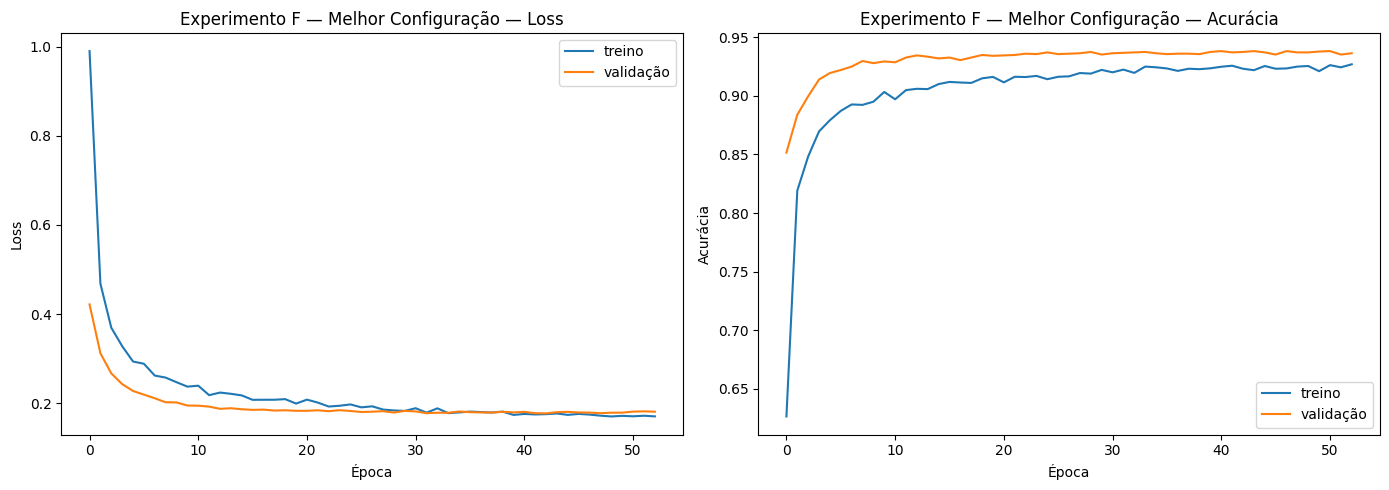

=== Experimento F — Melhor configuração ===
  Acurácia  : 0.9266
  F1-macro  : 0.9373

              precision    recall  f1-score   support

    BARBUNYA       0.91      0.92      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.95      0.93      0.94       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.88      0.88       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [58]:
tf.random.set_seed(42)
modelo_F = construir_modelo(
    n_entrada=X_train.shape[1],
    unidades=[256, 128, 64],
    taxas_dropout=[0.3, 0.2, 0.1],
    lr=5e-4,
)
historico_F = treinar(
    modelo_F, X_train, y_train, X_val, y_val, batch_size=128, usar_pesos=True
)
plotar_curvas(historico_F, "Experimento F — Melhor Configuração")

print("=== Experimento F — Melhor configuração ===")
acc_F, f1_F, y_pred_F = avaliar(modelo_F, X_test, y_test)


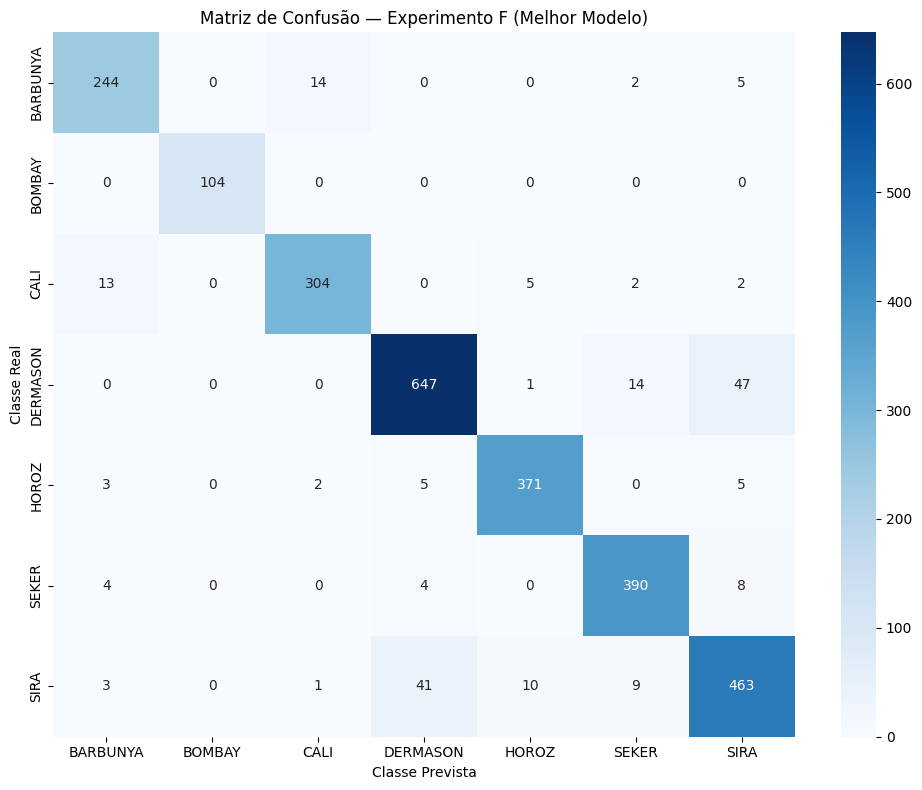

In [66]:
cm = confusion_matrix(y_test, y_pred_F)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
)
plt.title("Matriz de Confusão — Experimento F (Melhor Modelo)")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

# cm = confusion_matrix(y_test, y_pred_E)

# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=nomes_classes,
#     yticklabels=nomes_classes,
# )
# plt.title("Matriz de Confusão — Experimento E")
# plt.xlabel("Classe Prevista")
# plt.ylabel("Classe Real")
# plt.tight_layout()
# plt.show()

In [67]:
import joblib
# https://keras.io/api/callbacks/model_checkpoint/
CAMINHO_MODELO = "melhor_modelo.keras"
CAMINHO_SCALER = "scaler_final.pkl"
CAMINHO_ENCODER = "label_encoder.pkl"

tf.random.set_seed(42)
modelo_final = construir_modelo(
    n_entrada=X_train.shape[1],
    unidades=[256, 128, 64],
    taxas_dropout=[0.3, 0.2, 0.1],
    lr=5e-4,
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=CAMINHO_MODELO, monitor="val_loss", save_best_only=True, verbose=1
)
cb_early = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

modelo_final.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=128,
    callbacks=[cb_checkpoint, cb_early],
    class_weight=class_weight_dict,
    verbose=1,
)

# scales e label encoder é só estruturas basicas de python, só precisamos usar pkl
joblib.dump(scaler_final, CAMINHO_SCALER)
joblib.dump(le, CAMINHO_ENCODER)

Epoch 1/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4577 - loss: 1.7464
Epoch 1: val_loss improved from None to 0.45118, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6119 - loss: 1.1250 - val_accuracy: 0.8475 - val_loss: 0.4512
Epoch 2/300
58/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8067 - loss: 0.5167
Epoch 2: val_loss improved from 0.45118 to 0.30909, saving model to melhor_modelo.keras

Epoch 2: finished saving model to melhor_modelo.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8184 - loss: 0.4729 - val_accuracy: 0.8894 - val_loss: 0.3091
Epoch 3/300
58/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8506 - loss: 0.3944
Epoch 3: val_loss improved from 0.30909 to 0.26441, saving model to melhor_modelo.keras

Epoch 3: finished saving model to melhor_modelo.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8484 - loss: 0.3904 - val_accurac

['label_encoder.pkl']

In [ ]:
# streamlit

import streamlit as st
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

CAMINHO_MODELO = "melhor_modelo.keras"
CAMINHO_SCALER = "scaler_final.pkl"
CAMINHO_ENCODER = "label_encoder.pkl"


@st.cache_resource
def carregar_modelo():
    modelo = tf.keras.models.load_model(CAMINHO_MODELO)
    scaler = joblib.load(CAMINHO_SCALER)
    encoder = joblib.load(CAMINHO_ENCODER)
    return modelo, scaler, encoder


modelo, scaler, encoder = carregar_modelo()

st.title("Classificador com Rede Neural")

st.write("Insira os valores das features:")


feature_names = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRatio",
    "Eccentricity",
    "ConvexArea",
    "EquivDiameter",
    "Extent",
    "Solidity",
    "Roundness",
    "Compactness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor3",
    "ShapeFactor4",
]

inputs = []


for i, feature in enumerate(feature_names):
    val = st.number_input(feature, value=0.0)
    inputs.append(val)

entrada = np.array(inputs).reshape(1, -1)

if st.button("Prever"):
    entrada_scaled = scaler.transform(entrada)

    probs = modelo.predict(entrada_scaled)[0]
    classe_idx = np.argmax(probs)
    classe_nome = encoder.inverse_transform([classe_idx])[0]

    st.subheader(f"Classe prevista: {classe_nome}")

    fig, ax = plt.subplots()
    ax.bar(encoder.classes_, probs)
    ax.set_ylabel("Probabilidade")
    ax.set_xlabel("Classe")
    ax.set_title("Distribuição de Probabilidades")

    st.pyplot(fig)
